# Verify a sham-feeding NWB

Sanity checks for a converted sham-feeding session (set `NWB_PATH` to point to the nwb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

NWB_PATH = "IM1923_SF5-Sucrose_20251106.nwb"
# gACh4h 470 (green), rDA3m 565 (red), 405 reference (desaturated green)
WAVELENGTH_COLORS = {470: "#2CA02C", 565: "#D62728", 405: "#8FBF8F"}

io = NWBHDF5IO(NWB_PATH, mode="r")
nwb = io.read()


def time_vector(timeseries):
    """Time vector (seconds) for a TimeSeries, whether it uses rate or explicit timestamps."""
    if timeseries.timestamps is not None:
        return np.asarray(timeseries.timestamps[:])
    n_samples = timeseries.data.shape[0]
    start = timeseries.starting_time if timeseries.starting_time is not None else 0.0
    return start + np.arange(n_samples) / timeseries.rate


# Photometry (raw/filtered/hampel) and digital sync live in nwb.acquisition, 
# behavior and dlc live in processing modules
behavior = nwb.processing["behavior"]
dlc = nwb.processing["dlc"]

# Each recording side is named hemisphere_region (e.g. "left_mNacSh")
SIDES = list(nwb.processing["session_metadata"]["session_side_metadata"].to_dataframe()["side_label"])
print("sides:", SIDES)
print(nwb)

sides: ['left_mNacSh', 'right_NacCore']
root pynwb.file.NWBFile at 0x4832114544
Fields:
  acquisition: {
    digital_sync_left_mNacSh <class 'pynwb.base.TimeSeries'>,
    digital_sync_right_NacCore <class 'pynwb.base.TimeSeries'>,
    filt_405_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    filt_405_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    filt_470_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    filt_470_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    filt_565_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    filt_565_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_405_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_405_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_470_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_470_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_565_left_mNacSh <class 'abc.FiberPhotome

## Session / subject metadata

In [2]:
subject = nwb.subject
print("session_id:        ", nwb.session_id)
print("session_start_time:", nwb.session_start_time)
print("experimenter:      ", nwb.experimenter)
print("institution / lab: ", nwb.institution, "/", nwb.lab)
print("subject:           ", subject.subject_id, subject.species, subject.sex, subject.strain,
      "DOB", subject.date_of_birth)
print("\nnotes:\n", nwb.notes)

nwb.processing["session_metadata"]["session_side_metadata"].to_dataframe().T

session_id:         IM1923_SF5-Sucrose_20251106
session_start_time: 2025-11-06 09:31:35.090000-08:00
experimenter:       ('Slomp, Margo',)
institution / lab:  University of California, San Francisco / Berke Lab
subject:            IM1923 Rattus norvegicus M WT (PV-) DOB 2025-04-29 00:00:00-07:00

notes:
 Sham-feeding SF5-Sucrose trial. Left hemisphere (COM3) recorded from mNacSh (target mNacSh); Right hemisphere (COM4) recorded from NacCore (target NacCore). Grams consumed: 81.82 g; grams in pan: 80.84 g. pyPhotometry mode '3EX_2EM_pulsed', sampling rate 86 Hz, LED current [10, 47] mA, volts/division [0.00010122, 0.00010122].


id,0,1
side_label,left_mNacSh,right_NacCore
side,Left,Right
com_port,COM3,COM4
region,mNacSh,NacCore
hemisphere,left,right
hit,mNacSh,NacCore
target,mNacSh,NacCore
full_side_name,COM3_Left_mNacSh,COM4_Right_NacCore
indicator_470nm,gACh4h,gACh4h
indicator_565nm,rDA3m,rDA3m


## Photometry signals: full session, both hemispheres (raw / filtered / hampel)

One figure per processing level (raw, pyPhotometry-filtered, hampel-cleaned) per side, each with three subplots (470 signal, 405 reference, 565 rDA3m)

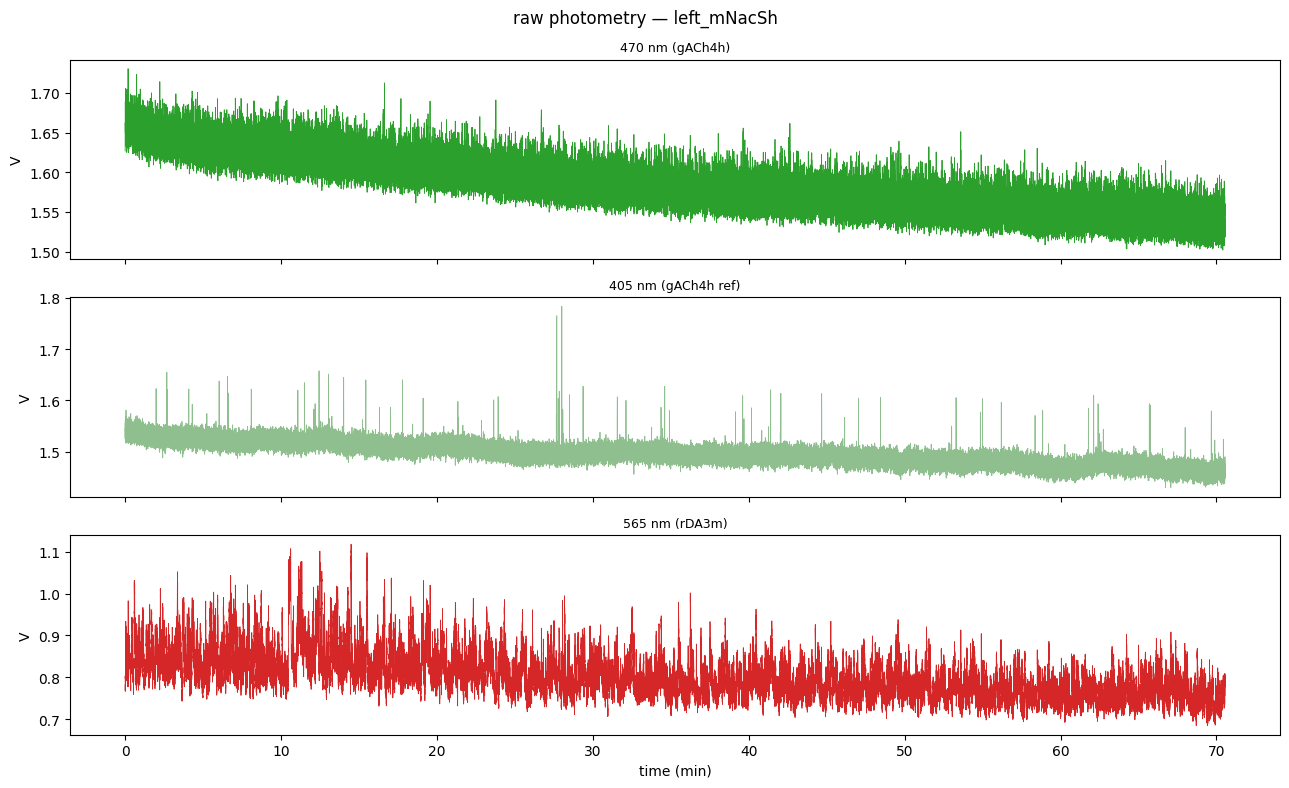

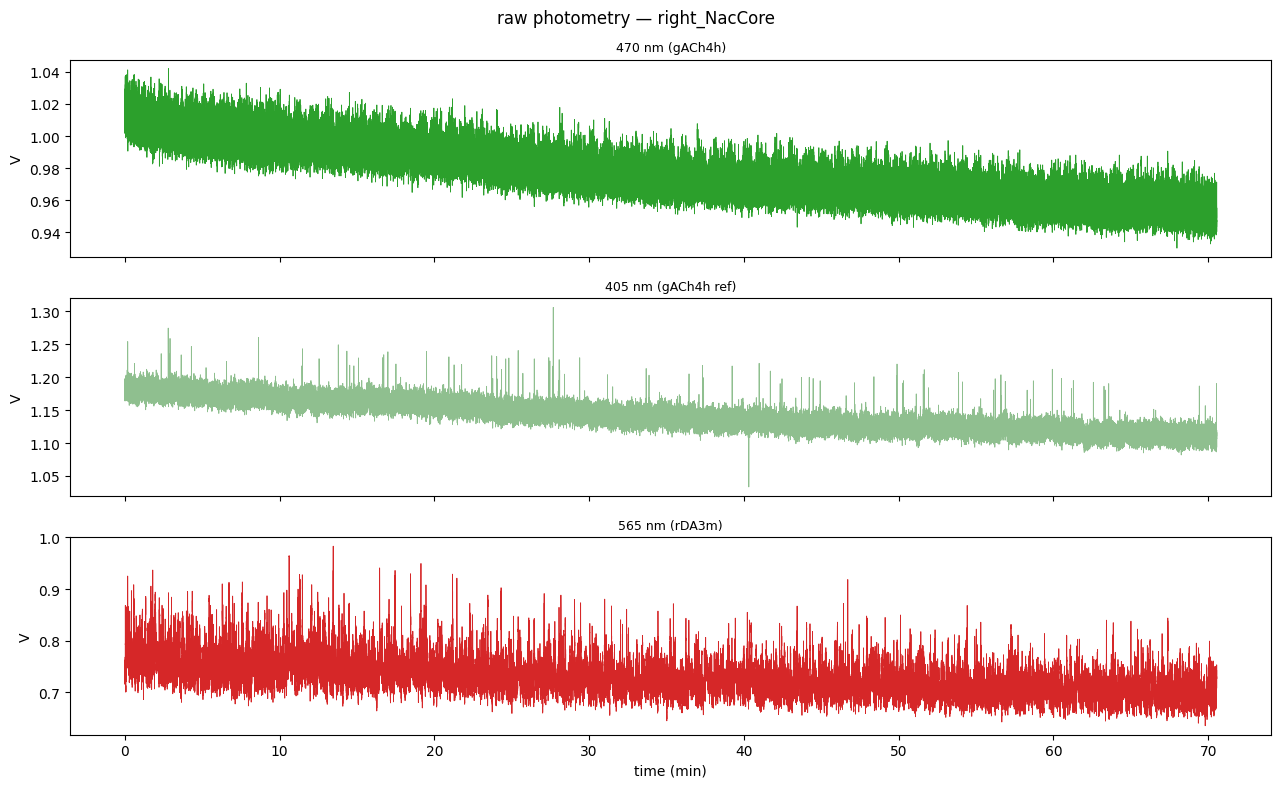

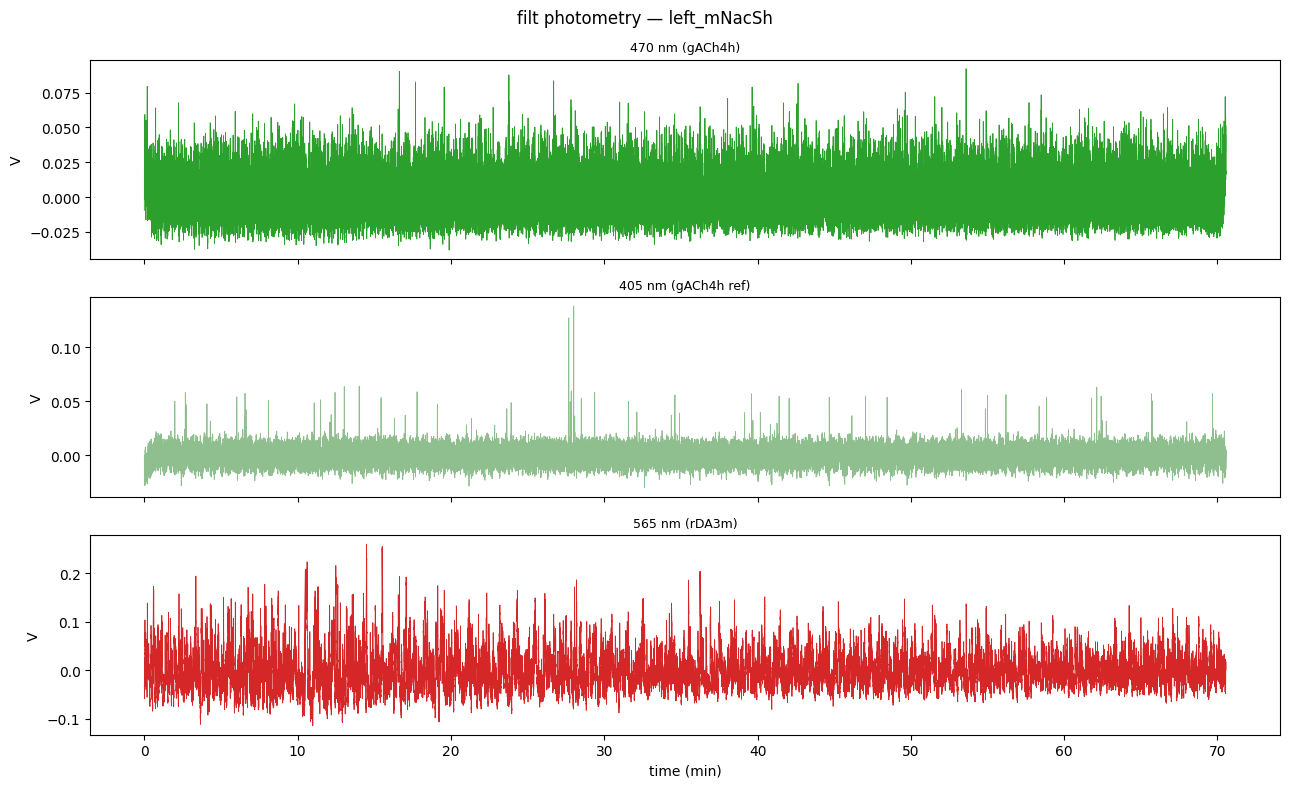

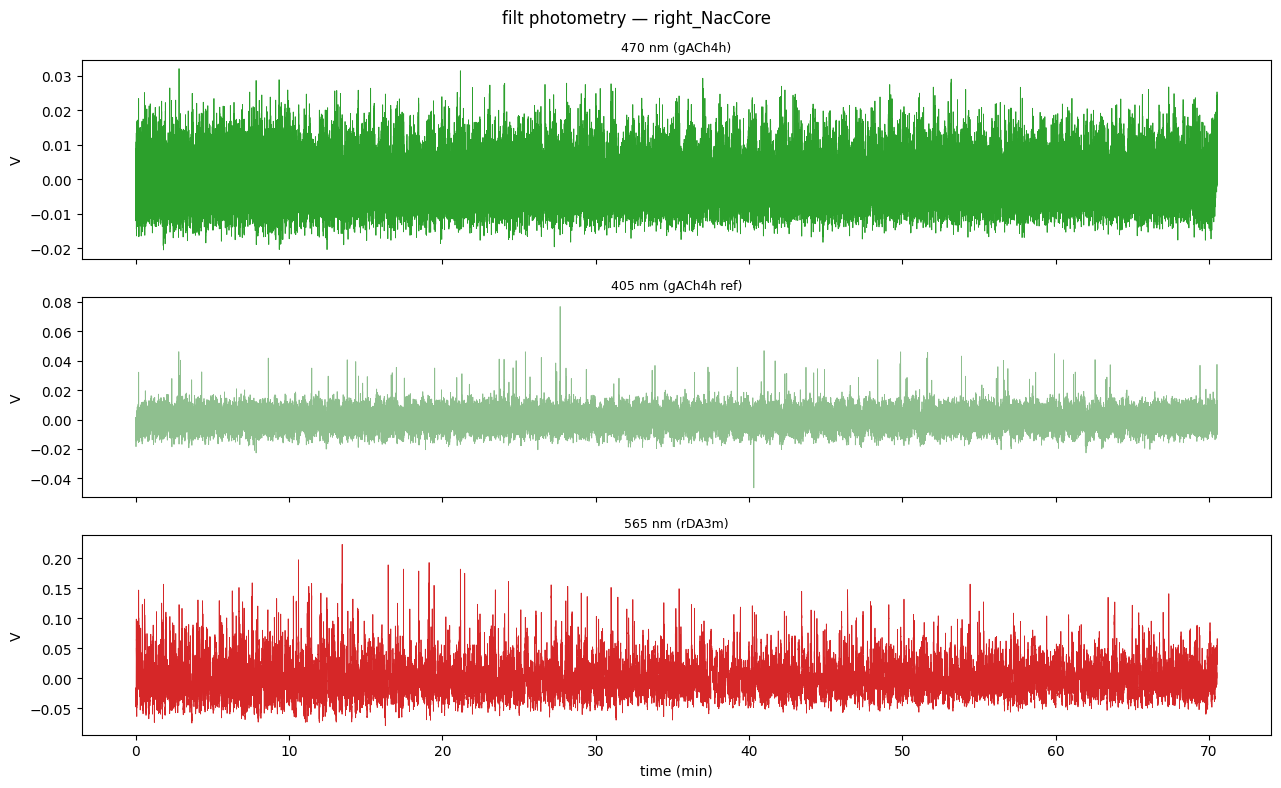

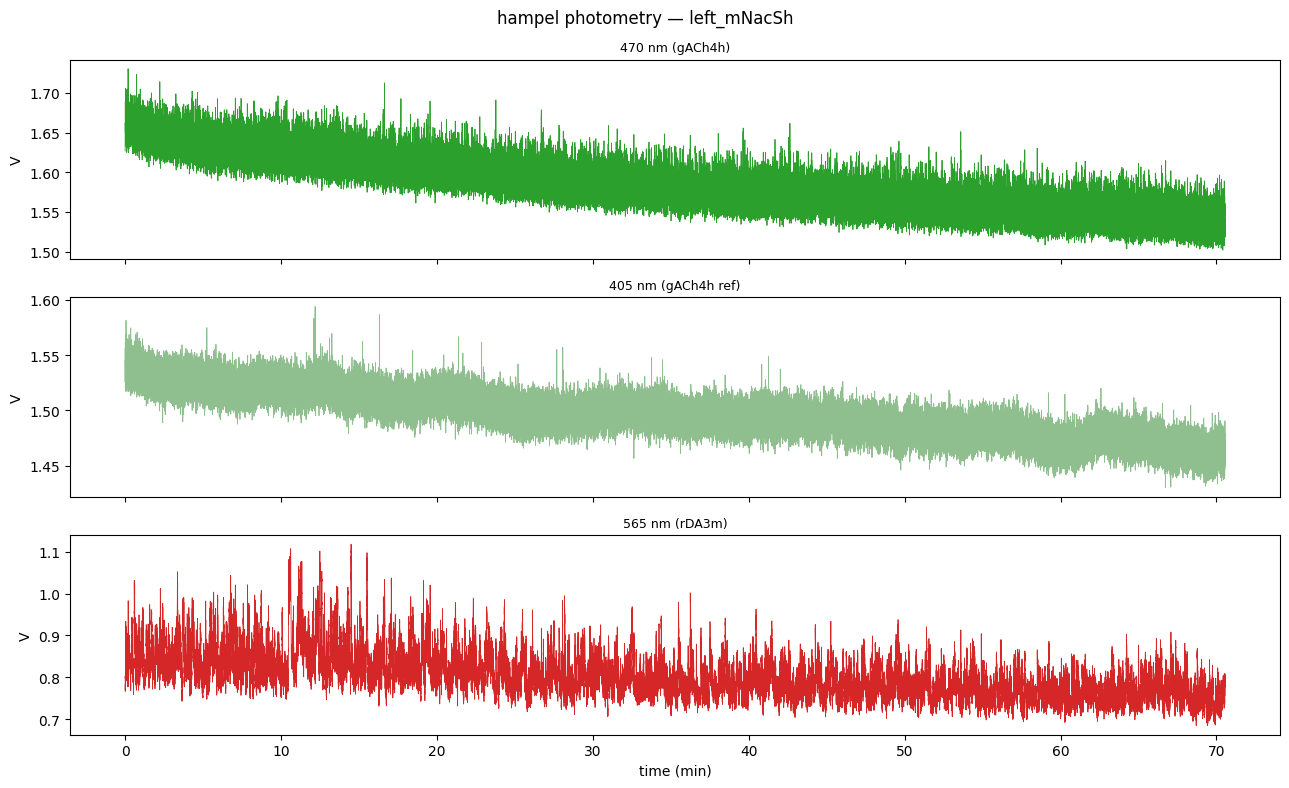

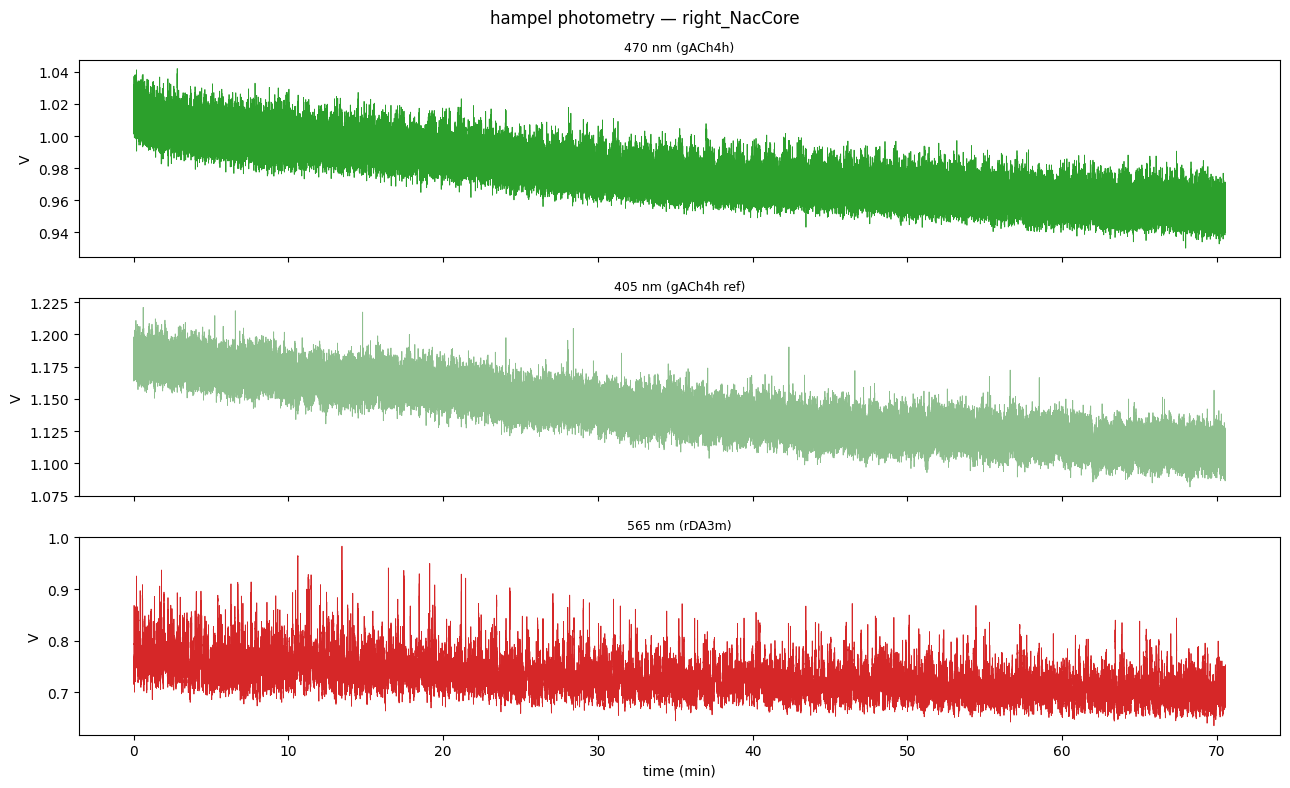

In [3]:
WAVELENGTH_SENSOR = {470: "gACh4h", 565: "rDA3m", 405: "gACh4h ref"}
# One figure per (processing level x side), 3 subplots (one per wavelength: 470 signal, 405 ref, 565 rDA3m)
for level in ("raw", "filt", "hampel"):
    for side_label in SIDES:
        fig, ax = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
        for axis, wavelength in zip(ax, (470, 405, 565)):
            photometry = nwb.acquisition[f"{level}_{wavelength}_{side_label}"]
            axis.plot(time_vector(photometry) / 60, photometry.data[:], color=WAVELENGTH_COLORS[wavelength], lw=0.6)
            axis.set_ylabel("V"); axis.set_title(f"{wavelength} nm ({WAVELENGTH_SENSOR[wavelength]})", fontsize=9)
        ax[-1].set_xlabel("time (min)")
        fig.suptitle(f"{level} photometry — {side_label}")
        fig.tight_layout()

## Licking overview (cumulative licks, lick rate, burst structure)

left_mNacSh: 74 bursts, mean 301 licks/burst, mean burst dur 18.8 s
right_NacCore: 74 bursts, mean 301 licks/burst, mean burst dur 18.8 s


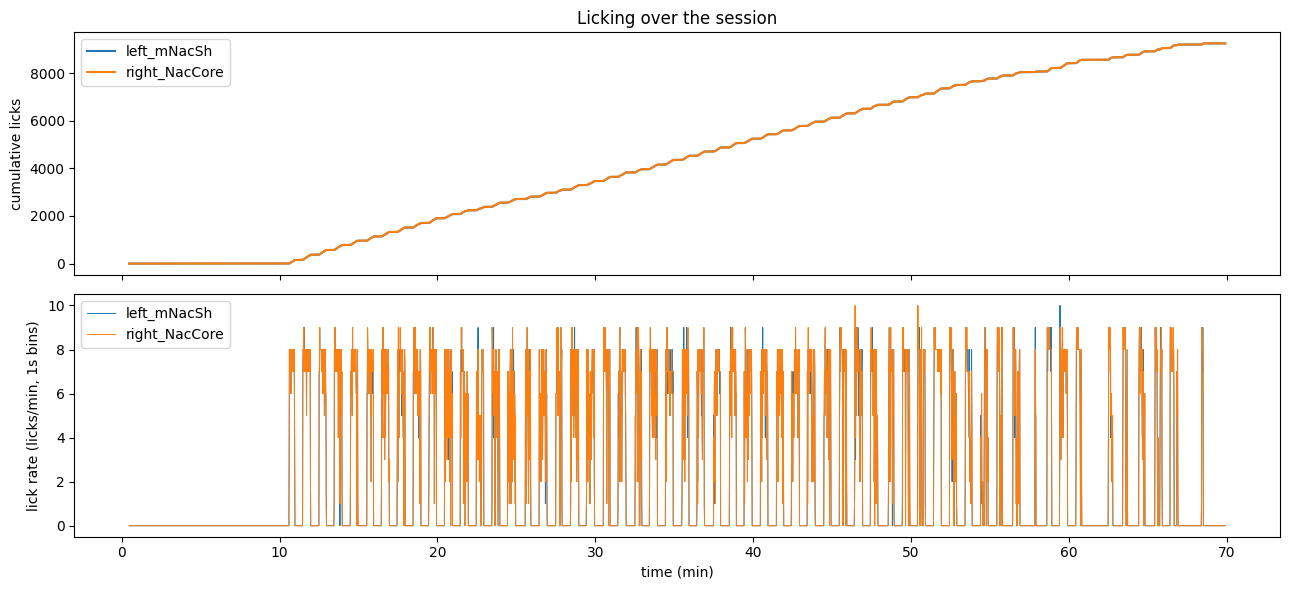

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for side_label in SIDES:
    cumulative_licks = behavior[f"cumulative_licks_{side_label}"]
    axes[0].plot(time_vector(cumulative_licks) / 60, cumulative_licks.data[:], label=side_label)
    # A no-lick session has no lick-rate series.
    rate_name = f"lickrate_1s_{side_label}"
    if rate_name in behavior.data_interfaces:
        lick_rate = behavior[rate_name]
        axes[1].plot(time_vector(lick_rate) / 60, lick_rate.data[:], lw=0.7, label=side_label)
axes[0].set_ylabel("cumulative licks"); axes[0].legend()
axes[1].set_ylabel("lick rate (licks/min, 1s bins)"); axes[1].set_xlabel("time (min)")
if axes[1].lines:
    axes[1].legend()
axes[0].set_title("Licking over the session")
fig.tight_layout()

for side_label in SIDES:
    burst_df = behavior[f"burst_table_{side_label}"].to_dataframe()
    if len(burst_df) == 0:
        print(f"{side_label}: no licks/bursts recorded")
        continue
    print(f"{side_label}: {len(burst_df)} bursts, mean {burst_df['avg_licks_per_burst'].mean():.0f} licks/burst, "
          f"mean burst dur {burst_df['lick_burst_duration_ms'].mean()/1000:.1f} s")

## Alignment check: zoom in on photometry + licks + engagement + DLC distance

A 60 s window mid-session. Check that licks, engagement and short head-to-spout distance line up. May see a DA transient at the start of a bout!

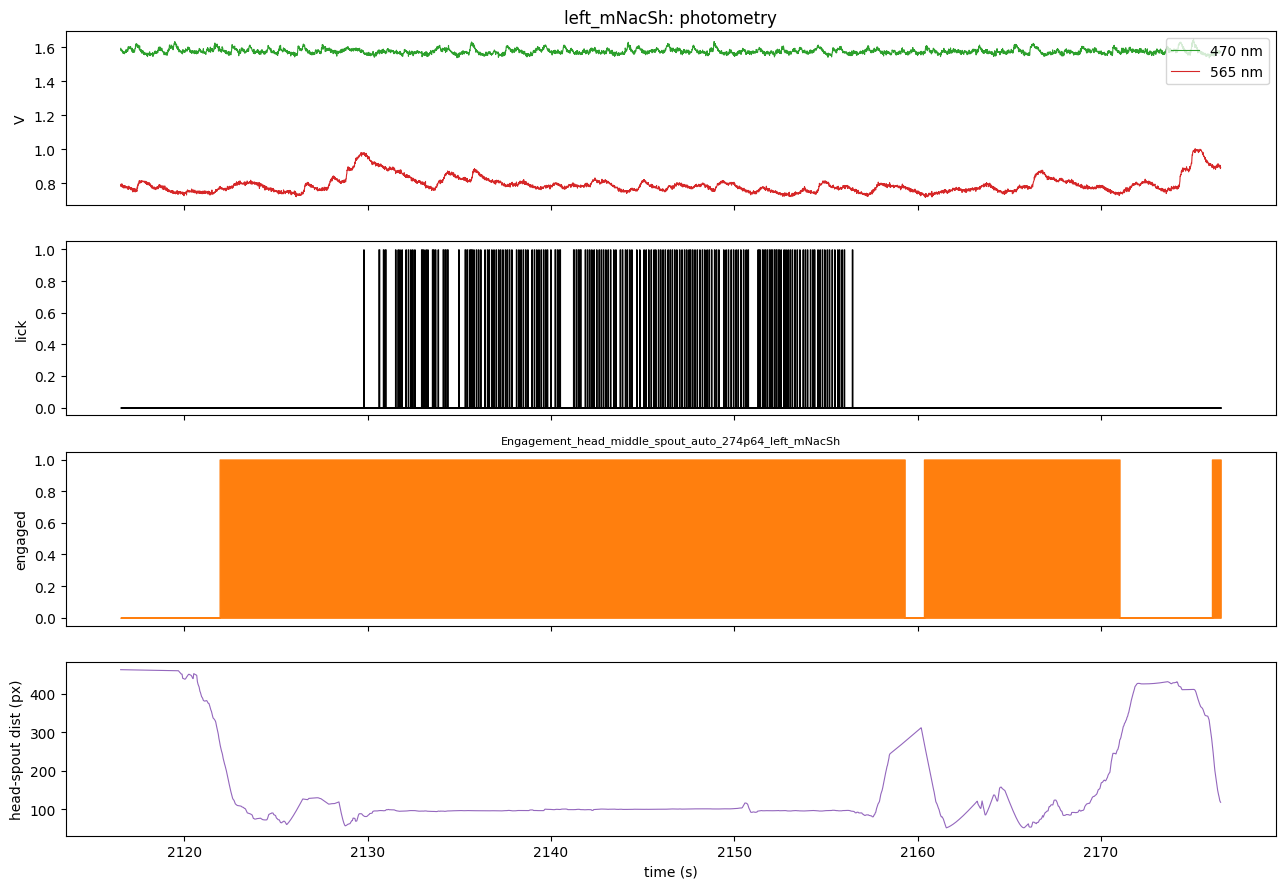

In [5]:
side_label = SIDES[0]
reference = nwb.acquisition[f"raw_470_{side_label}"]
total_s = reference.data.shape[0] / reference.rate
zoom_start_s, zoom_duration_s = total_s / 2, 60   # 60 s window centered mid-session


def window(timeseries, start_s, duration_s):
    """(times, values) of a TimeSeries within [start_s, start_s + duration_s]."""
    times = time_vector(timeseries)
    in_window = (times >= start_s) & (times <= start_s + duration_s)
    return times[in_window], np.asarray(timeseries.data[:])[in_window]


fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

for wavelength in (470, 565):
    times, values = window(nwb.acquisition[f"raw_{wavelength}_{side_label}"], zoom_start_s, zoom_duration_s)
    axes[0].plot(times, values, color=WAVELENGTH_COLORS[wavelength], lw=0.8, label=f"{wavelength} nm")
axes[0].set_ylabel("V"); axes[0].legend(loc="upper right"); axes[0].set_title(f"{side_label}: photometry")

times, values = window(behavior[f"lick_binary_{side_label}"], zoom_start_s, zoom_duration_s)
axes[1].fill_between(times, 0, np.nan_to_num(values), step="mid", color="k"); axes[1].set_ylabel("lick")

# the auto-threshold head-to-spout engagement vector for this side
engagement_key = [name for name in behavior.data_interfaces
                  if name.startswith("Engagement") and name.endswith(side_label) and "auto" in name][0]
times, values = window(behavior[engagement_key], zoom_start_s, zoom_duration_s)
axes[2].fill_between(times, 0, values, step="mid", color="tab:orange"); axes[2].set_ylabel("engaged")
axes[2].set_title(engagement_key, fontsize=8)

times, values = window(dlc[f"DLC_Distance_head_middle_spout_{side_label}"], zoom_start_s, zoom_duration_s)
axes[3].plot(times, values, color="tab:purple", lw=0.8)
axes[3].set_ylabel("head-spout dist (px)"); axes[3].set_xlabel("time (s)")
fig.tight_layout()

## Photometry signals aligned to lick-bout onset

Average raw signal around the first lick of each burst (bout onset)

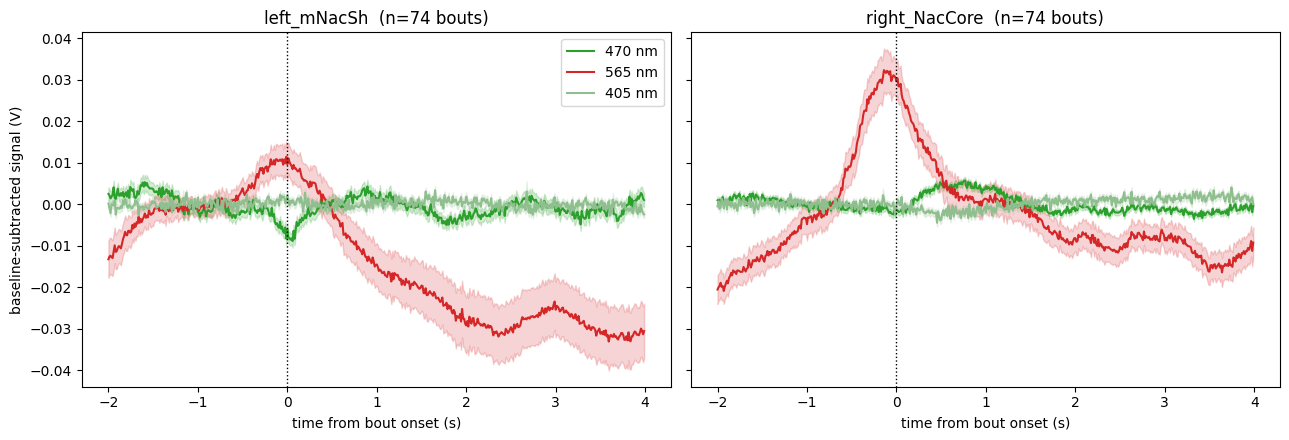

In [6]:
def bout_onsets(side_label, min_gap_s=2.0):
    """Lick-event times separated by >= min_gap_s, i.e. the first lick of each bout."""
    lick_events = behavior[f"lick_events_{side_label}"]
    event_times = np.asarray(lick_events.timestamps[:])
    if event_times.size == 0:
        return event_times
    keep = np.concatenate([[True], np.diff(event_times) >= min_gap_s])
    return event_times[keep]


def peri_event(timeseries, event_times, pre_s=2.0, post_s=4.0):
    """Stack signal snippets around each event time, baseline-subtracted on the pre-window."""
    times = time_vector(timeseries)
    values = np.asarray(timeseries.data[:])
    fs = timeseries.rate if timeseries.rate is not None else 1.0 / np.median(np.diff(times))
    n_pre, n_post = int(pre_s * fs), int(post_s * fs)
    lag = np.arange(-n_pre, n_post) / fs
    snippets = []
    for event_time in event_times:
        idx = int(round((event_time - times[0]) * fs))
        if idx - n_pre >= 0 and idx + n_post < len(values):
            segment = values[idx - n_pre: idx + n_post].astype(float)
            snippets.append(segment - np.nanmean(segment[:n_pre]))   # baseline-subtract pre-window
    return lag, np.array(snippets)


# A no-lick session has no bouts, so every side here plots empty (n=0).
fig, axes = plt.subplots(1, len(SIDES), figsize=(13, 4.5), sharey=True)
for ax, side_label in zip(axes, SIDES):
    onset_times = bout_onsets(side_label)
    for wavelength in (470, 565, 405):
        lag, snippets = peri_event(nwb.acquisition[f"raw_{wavelength}_{side_label}"], onset_times)
        if snippets.size == 0:
            continue
        mean_trace = snippets.mean(0)
        sem = snippets.std(0) / np.sqrt(len(snippets))
        ax.plot(lag, mean_trace, color=WAVELENGTH_COLORS[wavelength], label=f"{wavelength} nm")
        ax.fill_between(lag, mean_trace - sem, mean_trace + sem, color=WAVELENGTH_COLORS[wavelength], alpha=0.2)
    ax.axvline(0, color="k", ls=":", lw=1)
    ax.set_title(f"{side_label}  (n={len(onset_times)} bouts)")
    ax.set_xlabel("time from bout onset (s)")
axes[0].set_ylabel("baseline-subtracted signal (V)")
if axes[0].lines:
    axes[0].legend()
fig.tight_layout()

## Photometry signals aligned to spout approach

Uses the `approach_events` from the distance-state detection

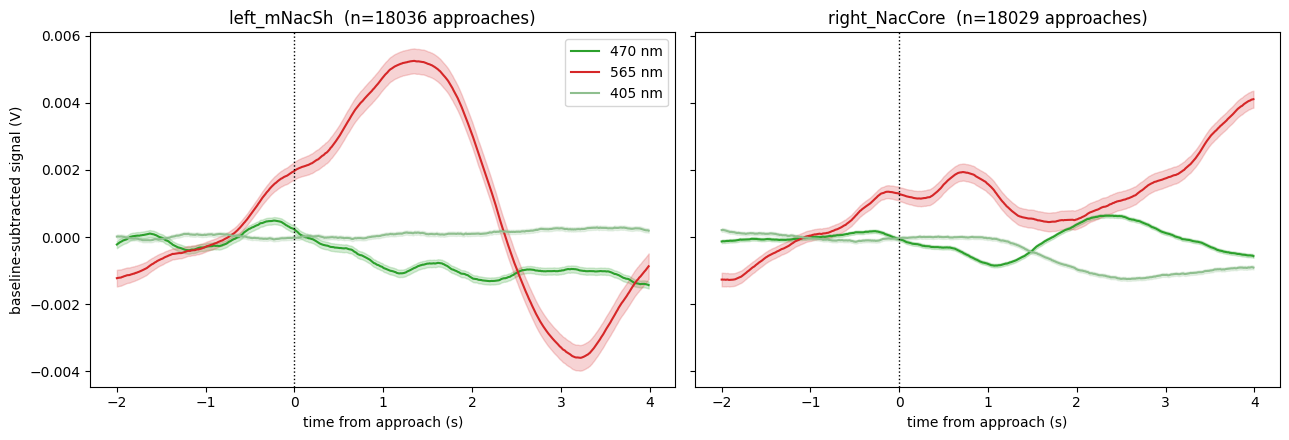

In [7]:
fig, axes = plt.subplots(1, len(SIDES), figsize=(13, 4.5), sharey=True)
for ax, side_label in zip(axes, SIDES):
    approach = behavior[f"approach_events_{side_label}"]
    approach_times = time_vector(approach)[np.asarray(approach.data[:]) > 0]
    for wavelength in (470, 565, 405):
        lag, snippets = peri_event(nwb.acquisition[f"raw_{wavelength}_{side_label}"], approach_times)
        if snippets.size == 0:
            continue
        mean_trace = snippets.mean(0)
        sem = snippets.std(0) / np.sqrt(len(snippets))
        ax.plot(lag, mean_trace, color=WAVELENGTH_COLORS[wavelength], label=f"{wavelength} nm")
        ax.fill_between(lag, mean_trace - sem, mean_trace + sem, color=WAVELENGTH_COLORS[wavelength], alpha=0.2)
    ax.axvline(0, color="k", ls=":", lw=1)
    ax.set_title(f"{side_label}  (n={len(approach_times)} approaches)")
    ax.set_xlabel("time from approach (s)")
axes[0].set_ylabel("baseline-subtracted signal (V)"); axes[0].legend()
fig.tight_layout()

## Print everything in the file

In [8]:
print("ACQUISITION (raw + filtered + hampel photometry, digital sync):")
for name, obj in nwb.acquisition.items():
    print(f"  {name:34s} {getattr(obj.data, 'shape', '?')}")
for module_name in ("behavior", "dlc", "session_metadata"):
    print(f"\n{module_name.upper()}:")
    for name in nwb.processing[module_name].data_interfaces:
        print(f"  {name}")

ACQUISITION (raw + filtered + hampel photometry, digital sync):
  digital_sync_left_mNacSh           (364042,)
  digital_sync_right_NacCore         (364047,)
  filt_405_left_mNacSh               (364042,)
  filt_405_right_NacCore             (364047,)
  filt_470_left_mNacSh               (364042,)
  filt_470_right_NacCore             (364047,)
  filt_565_left_mNacSh               (364042,)
  filt_565_right_NacCore             (364047,)
  hampel_405_left_mNacSh             (364042,)
  hampel_405_right_NacCore           (364047,)
  hampel_470_left_mNacSh             (364042,)
  hampel_470_right_NacCore           (364047,)
  hampel_565_left_mNacSh             (364042,)
  hampel_565_right_NacCore           (364047,)
  raw_405_left_mNacSh                (364042,)
  raw_405_right_NacCore              (364047,)
  raw_470_left_mNacSh                (364042,)
  raw_470_right_NacCore              (364047,)
  raw_565_left_mNacSh                (364042,)
  raw_565_right_NacCore              (36404

In [9]:
import pandas as pd

fiber_table_df = nwb.get_lab_meta_data("fiber_photometry").fiber_photometry_table.to_dataframe()
device_view = pd.DataFrame({
    "location": fiber_table_df["location"],
    "coords(AP,ML,DV)": [list(np.round(np.asarray(coords), 2)) for coords in fiber_table_df["coordinates"]],
    "indicator": [indicator.name for indicator in fiber_table_df["indicator"]],
    "excitation": [source.name for source in fiber_table_df["excitation_source"]],
    "fiber": [fiber.name for fiber in fiber_table_df["optical_fiber"]],
})
print(device_view.to_string(index=False))
print("\nsurgery:", nwb.surgery)
print("\nvirus:  ", nwb.virus)

location coords(AP,ML,DV)              indicator          excitation                                        fiber
  mNacSh [1.3, -1.6, 6.2]   gACh4h (left mNacSh) Thorlabs 470 nm LED   Doric 200um 10mm Optic Fiber (left mNacSh)
  mNacSh [1.3, -1.6, 6.2]    rDA3m (left mNacSh) Thorlabs 565 nm LED   Doric 200um 10mm Optic Fiber (left mNacSh)
  mNacSh [1.3, -1.6, 6.2]   gACh4h (left mNacSh) Thorlabs 405 nm LED   Doric 200um 10mm Optic Fiber (left mNacSh)
 NacCore  [1.7, 1.7, 6.8] gACh4h (right NacCore) Thorlabs 470 nm LED Doric 200um 10mm Optic Fiber (right NacCore)
 NacCore  [1.7, 1.7, 6.8]  rDA3m (right NacCore) Thorlabs 565 nm LED Doric 200um 10mm Optic Fiber (right NacCore)
 NacCore  [1.7, 1.7, 6.8] gACh4h (right NacCore) Thorlabs 405 nm LED Doric 200um 10mm Optic Fiber (right NacCore)

surgery: NAc fiber photometry. Target coordinates (male, mm from bregma): left medial NAc shell AP +1.3, ML -1.6, DV 6.2 from dura (fiber) / 6.4 (virus), 6 degree angle; right NAc core AP +1.7, ML +1.7

## Validate file

Validate file and confirm a sample of arrays (raw/filtered/hampel photometry, lick binary, cumulative licks, cleaned head distance) match the original `*_lickprocessed.pkl` exactly

In [10]:
from pynwb import validate

schema_errors = validate(paths=[NWB_PATH])
print(f"Schema validation: {len(schema_errors)} error(s)")
for error in schema_errors[:10]:
    print("  ", error)


# Confirm arrays match the source pickle exactly
import glob
import pickle
pickle_paths = sorted(glob.glob(f"{nwb.subject.subject_id}_*_lickprocessed.pkl"))
if not pickle_paths:
    print("\nSource pickle not found next to the notebook — skipping round-trip check.")
else:
    sides_data = pickle.load(open(pickle_paths[0], "rb"))

    def side_label_of(side_data):   # rebuild the side label the converter used, from Full_side_name
        parts = str(side_data["Full_side_name"]).split("_")
        region = next((r for r in ("NacCore", "mNacSh") if "_".join(parts[2:]).endswith(r)), "_".join(parts[2:]))
        return f"{parts[1].lower()}_{region}"
    side_data_by_label = {side_label_of(side_data): side_data for side_data in sides_data}

    checks = []
    def check(series_name, expected, store):
        actual = np.asarray(store[series_name].data[:])
        expected = np.asarray(expected, dtype="float64")
        checks.append((series_name, actual.shape == expected.shape and np.allclose(actual, expected, equal_nan=True)))

    for side_label in SIDES:
        side_data = side_data_by_label[side_label]
        burst_vars = side_data["LickBurst_Vars_BurstDefinitionILI_basedThresh2000"]
        check(f"raw_470_{side_label}", side_data["analog_1"], nwb.acquisition)
        check(f"raw_565_{side_label}", side_data["analog_2"], nwb.acquisition)
        check(f"raw_405_{side_label}", side_data["analog_3"], nwb.acquisition)
        check(f"filt_470_{side_label}", side_data["analog_1_filt"], nwb.acquisition)
        check(f"hampel_405_{side_label}", side_data["analog3_hampel"], nwb.acquisition)
        check(f"lick_binary_{side_label}", side_data["LickBinary_2.3"], behavior)
        check(f"cumulative_licks_{side_label}", burst_vars["CumLicks"], behavior)
        check(f"cleaned_head_distance_{side_label}", side_data["Cleaned_Head_Distance"], behavior)

    n_failed = sum(not ok for _, ok in checks)
    print(f"\nRound-trip vs {pickle_paths[0]}: {len(checks) - n_failed}/{len(checks)} arrays match exactly")
    for series_name, ok in checks:
        if not ok:
            print("  MISMATCH:", series_name)

Schema validation: 0 error(s)

Round-trip vs IM1923_Trial-SF5-Sucrose_11-06-2025_lickprocessed.pkl: 16/16 arrays match exactly


## Check cross-side clock drift

Quantify the relative clock drift between the two boxes using the shared rsync pulses (the data preserved for downstream cross-side correction).


Matched 3773 rsync pulses across sides; net drift +46.5 ms (~11 ppm). Within a side, all streams share one clock (exact).


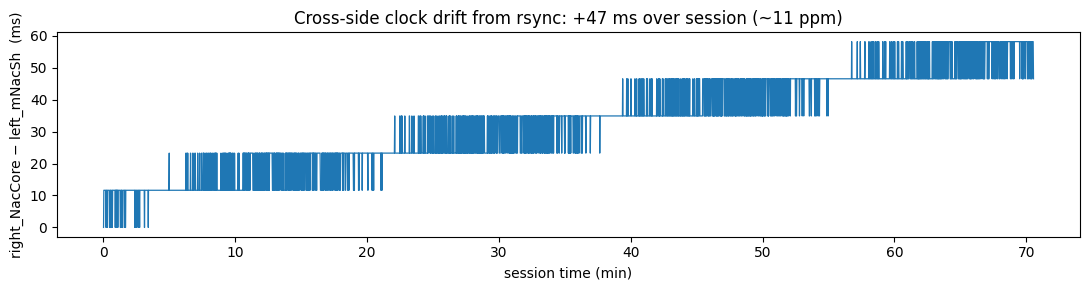

In [11]:
# Cross-side clock drift: match rsync pulses across the two sides. The boxes have independent
# crystals, so this should be a small slow ramp (~tens of ms)
side_a, side_b = SIDES[0], SIDES[1]
pulses_a = np.asarray(nwb.acquisition[f"rsync_pulse_times_{side_a}"].timestamps[:])
pulses_b = np.asarray(nwb.acquisition[f"rsync_pulse_times_{side_b}"].timestamps[:])
n_matched = min(len(pulses_a), len(pulses_b))
drift_ms = (pulses_b[:n_matched] - pulses_a[:n_matched]) * 1000
slope_ppm = np.polyfit(pulses_a[:n_matched], pulses_b[:n_matched] - pulses_a[:n_matched], 1)[0] * 1e6
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(pulses_a[:n_matched] / 60, drift_ms, lw=0.9)
ax.set_xlabel("session time (min)"); ax.set_ylabel(f"{side_b} − {side_a}  (ms)")
ax.set_title(f"Cross-side clock drift from rsync: "
             f"{drift_ms[-1] - drift_ms[0]:+.0f} ms over session (~{slope_ppm:.0f} ppm)")
fig.tight_layout()
print(f"\nMatched {n_matched} rsync pulses across sides; net drift {drift_ms[-1] - drift_ms[0]:+.1f} ms "
      f"(~{slope_ppm:.0f} ppm). Within a side, all streams share one clock (exact).")

In [12]:
io.close()